# **Asistente Experto en Nutrición y Entrenamiento Deportivo**
## **Proyecto Final - IA Generativa con Gemini + RAG + LangGraph**
###### *Elaborado por Soraya Malpica*
---

### **Descripción del Proyecto**

Este notebook implementa un **agente experto en nutrición y entrenamiento deportivo** que combina:

- **RAG (Retrieval-Augmented Generation)**: recupera contexto relevante de una base de conocimiento vectorial antes de responder
- **Google Gemini**: como LLM principal y motor de embeddings
- **ChromaDB**: base de datos vectorial para almacenar y consultar los documentos
- **LangGraph**: framework de agente con memoria de conversación entre turnos

### **Base de Conocimiento**

| Documento | Páginas | Contenido |
|-----------|---------|----------|
| `Doc1_Fundamentos_Nutricion_Deportiva.pdf` | 10 | Macronutrientes, hidratación, nutrición perioperativa |
| `Doc2_Planificacion_Entrenamiento.pdf` | 9 | Periodización, fuerza, resistencia, composición corporal |
| `Doc3_Recuperacion_Suplementacion.pdf` | 10 | Recuperación, suplementos, casos prácticos, lesiones |

### **Arquitectura del Sistema**

```
Usuario → [Pregunta] → LangGraph Agent
                            ↓
                    [Nodo: retrieve]
                    ChromaDB query (top-k chunks)
                            ↓
                    [Nodo: generate]
                    Gemini LLM + System Prompt
                    + Contexto RAG
                    + Historial conversación
                            ↓
                    [Respuesta] → Usuario
```
---

## **PASO 1 - Instalación de Dependencias y Configuración de Variables**

Este proyecto gestiona las dependencias con **`uv`**. Antes de ejecutar el notebook asegúrate de haberlo lanzado desde el entorno correcto:

```bash
# Opción A - uv lanza jupyter dentro del entorno automáticamente (recomendado)
uv run jupyter notebook asistente_deportivo_rag.ipynb

# Opción B - activar el entorno manualmente y luego abrir jupyter
source .venv/bin/activate        # Linux / macOS
.venv\\Scripts\\activate          # Windows
jupyter notebook asistente_deportivo_rag.ipynb
```

Si aún no has instalado las dependencias, ejecuta esto **en la terminal** (no en el notebook):
```bash
uv sync
```

### **PASO 1.A - Carga de Dependencias**

In [33]:
# Configuración de API Key y variables del entorno
from dotenv import load_dotenv
import os

load_dotenv()

# Procesamiento de Documentos PDF (Chunking)
import glob
from pathlib import Path
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Conocimiento vectorial y Embeddings
import chromadb
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_community.vectorstores import Chroma

# Costrucción del Agente con LangGraph
from typing import Annotated, List, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from IPython.display import Image, display, Markdown

### **PASO 1.B - Configuración de Constantes**

In [24]:
# Configuración de rutas
PDF_DIR = './docs'

PDF_FILES = [
    'Doc1_Fundamentos_Nutricion_Deportiva.pdf',
    'Doc2_Planificacion_Entrenamiento.pdf',
    'Doc3_Recuperacion_Suplementacion.pdf'
]

# API Key
API_KEY = os.getenv("GEMINI_API_KEY")
MODEL_EMBEDDING = 'gemini-embedding-001'
MODEL_LLM = 'gemini-2.5-flash'

# Creación y carga de colección ChormaDB
CHROMA_DIR = './chroma_db'
COLLECTION_NAME = 'nutricion_deportiva'

## **PASO 2 - Carga y Procesamiento de Documentos PDF (Chunking)**
Procesamos los 3 PDFs con:
- **Chunk size**: 800 tokens, suficiente para capturar tablas y párrafos completos
- **Chunk overlap**: 100 tokens, evita perder contexto en los bordes de los chunks
- **Separadores semánticos**: prioriza separar por párrafos, luego por frases

### **PASO 2.A - Carga de PDFs**

In [9]:
documentos = []

for pdf_file in PDF_FILES:
    pdf_path = os.path.join(PDF_DIR, pdf_file)
    
    if not os.path.exists(pdf_path):
        print(f'No encontrado: {pdf_path} - asegúrate de colocar los PDFs en "{PDF_DIR}"')
        continue
    
    carga = PyPDFLoader(pdf_path)
    docs = carga.load()
    
    # Añadir metadatos a cada página
    # for doc in docs:
    #     doc.metadata["source_file"] = pdf_file
    #     doc.metadata["domain"] = "nutricion_deportiva"
    
    documentos.extend(docs)
    print(f"{pdf_file}: {len(docs)} páginas cargadas")

print(f"\nTotal páginas cargadas: {len(documentos)}")

Doc1_Fundamentos_Nutricion_Deportiva.pdf: 10 páginas cargadas
Doc2_Planificacion_Entrenamiento.pdf: 9 páginas cargadas
Doc3_Recuperacion_Suplementacion.pdf: 10 páginas cargadas

Total páginas cargadas: 29


### **PASO 2.B - Chunking**

In [10]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,           # 800 caracteres por chunk
    chunk_overlap=100,        # Solapamiento para preservar contexto
    length_function=len,
    separators=['\n\n', '\n', '. ', ' ', '']  # Separación semántica
)

chunks = text_splitter.split_documents(documentos)

print(f'-> Total chunks generados: {len(chunks)}')
print(f'-> Tamaño medio de chunk: {sum(len(c.page_content) for c in chunks) // len(chunks)} caracteres')

# Ejemplo de chunk
print('\nEjemplo de chunk')
print(f'Fuente: {chunks[5].metadata.get('source_file', 'N/A')} | Página: {chunks[5].metadata.get('page', 'N/A')}')
print(chunks[5].page_content[:300] + '...')

-> Total chunks generados: 77
-> Tamaño medio de chunk: 626 caracteres

Ejemplo de chunk
Fuente: N/A | Página: 2
CAPÍTULO 2: MACRONUTRIENTES EN EL DEPORTE
2.1 Carbohidratos: El Combustible Principal
Los carbohidratos (CHO) son la fuente de energía preferida por el músculo esquelético durante el ejercicio
de intensidad moderada-alta. Se almacenan en forma de glucógeno en el músculo (aproximadamente
400-500 g) y...


## PASO 3 - **Creación de la Base de Conocimiento Vectorial** (ChromaDB + Gemini Embeddings)

Indexamos todos los chunks en ChromaDB usando **gemini-embedding-001**, un modelo de incrustación de texto de alto rendimiento de Google (lanzado en octubre de 2025) que ofrece soporte multilingüe avanzado para búsqueda, recuperación y clasificación semántica

In [18]:
embeddings = GoogleGenerativeAIEmbeddings(
    model=MODEL_EMBEDDING,
    google_api_key=API_KEY
)

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    # collection_name=COLLECTION_NAME,
    # persist_directory=CHROMA_DIR
)

In [20]:
# Verificación que ChromaDB responde correctamente ANTES de conectar el agente

retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 4}  # Recupera los 4 chunks más relevantes
)

test_queries = [
    "¿Cuánta proteína necesita un deportista de fuerza?",
    "¿Qué es la periodización por bloques?",
    "¿Para qué sirve la creatina?"
]

print("TEST DE LA BASE VECTORIAL\n" + "-"*50)
for query in test_queries:
    results = retriever.invoke(query)
    print(f"\nQuery: '{query}'")
    print(f"\t-> {len(results)} chunks recuperados")
    for i, doc in enumerate(results[:2]):
        print(f"\tChunk {i+1} [{doc.metadata.get('source','?')} | pág.{doc.metadata.get('page','?')}]:")
        print(f"\t{doc.page_content[:120]}...")

print("\n✅ ChromaDB responde correctamente a las consultas")

TEST DE LA BASE VECTORIAL
--------------------------------------------------

Query: '¿Cuánta proteína necesita un deportista de fuerza?'
	-> 4 chunks recuperados
	Chunk 1 [./docs\Doc1_Fundamentos_Nutricion_Deportiva.pdf | pág.2]:
	deportistas, los requerimientos proteicos son significativamente superiores a los de la población general
(0.8 g/kg/día)...
	Chunk 2 [./docs\Doc3_Recuperacion_Suplementacion.pdf | pág.6]:
	CAPÍTULO 4: CASOS PRÁCTICOS Y PREGUNTAS
FRECUENTES
4.1 Caso Práctico 1: ¿Cuánta proteína necesito si voy al gimnasio 3
d...

Query: '¿Qué es la periodización por bloques?'
	-> 4 chunks recuperados
	Chunk 1 [./docs\Doc2_Planificacion_Entrenamiento.pdf | pág.2]:
	que buscan desarrollar simultáneamente fuerza, hipertrofia y resistencia muscular.
Ejemplo de DUP semanal para entrenami...
	Chunk 2 [./docs\Doc2_Planificacion_Entrenamiento.pdf | pág.3]:
	 Bloque de acumulación: alto volumen, intensidad moderada. Construye la base de condición física.
 Bloque de transmuta...

Que

## **PASO 4 - Diseño del System Prompt**

### **PASO 4.A - System Prompt: Justificación de Decisiones de Diseño**

El system prompt define la **identidad, comportamiento y limitaciones** del agente. Se han tomado las siguientes decisiones:

| Decisión | Justificación |
|----------|---------------|
| **Rol de entrenador experto** | Define un perfil de autoridad en el dominio sin ser médico, lo que equilibra credibilidad con responsabilidad |
| **Tono cercano pero técnico** | El público objetivo son personas interesadas en mejorar su rendimiento; valoran datos precisos con lenguaje accesible |
| **Prioriza el contexto RAG** | Instruye explícitamente a basar las respuestas en los documentos, reduciendo alucinaciones |
| **Admite incertidumbre** | Si no hay información en la base de conocimiento, lo dice claramente en lugar de inventar |
| **Incluye cifras cuando están disponibles** | Los documentos contienen datos numéricos concretos (dosis, rangos, porcentajes); el prompt incentiva usarlos |
| **Disclaimer médico** | Las recomendaciones de nutrición y ejercicio tienen implicaciones de salud; se incluye aviso de consultar profesional |
| **Conciencia del historial** | El prompt indica explícitamente que debe usar el historial de conversación para mantener coherencia |

In [22]:
SYSTEM_PROMPT = '''
Eres un asistente experto en nutrición deportiva y planificación del entrenamiento físico.
Tu base de conocimiento incluye información detallada sobre macronutrientes, periodización del
entrenamiento, suplementación deportiva, recuperación y estrategias de composición corporal.

## TU ROL
Actúas como un entrenador personal y nutricionista deportivo con formación científica. Respondes
preguntas sobre nutrición, entrenamiento, suplementación y recuperación de forma clara, precisa
y basada en evidencia.

## CÓMO RESPONDER
1. Basa SIEMPRE tus respuestas en el CONTEXTO RECUPERADO que se te proporciona. Ese contexto
   proviene de documentos especializados en nutrición y entrenamiento deportivo.
2. Incluye datos concretos cuando estén disponibles (dosis, rangos, porcentajes, tiempos).
3. Estructura tus respuestas con claridad: usa listas o párrafos según convenga.
4. Si el contexto no contiene información suficiente para responder la pregunta, dilo
   explícitamente: "No tengo información suficiente en mi base de conocimiento sobre esto."
   No inventes datos ni hagas suposiciones sin base.
5. Usa el HISTORIAL DE CONVERSACIÓN para mantener coherencia entre turnos: si el usuario
   hace referencia a algo mencionado antes, conecta la respuesta con ese contexto previo.
6. Adapta el nivel técnico al usuario: si usa terminología avanzada, responde en el mismo
   nivel; si parece principiante, explica los conceptos básicos primero.

## LIMITACIONES
- No eres médico. Para condiciones médicas específicas, lesiones graves o patologías,
  recomienda siempre consultar con un profesional de la salud.
- No prescribes medicamentos ni tratas enfermedades.
- Si alguien pregunta sobre algo fuera de tu dominio (nutrición/entrenamiento),
  indica amablemente que estás especializado en ese ámbito.

## TONO
Cercano, motivador y profesional. Usa un lenguaje accesible pero técnicamente riguroso.
Evita respuestas excesivamente largas; sé directo y útil.
'''

## **PASO 5 - Construcción del Agente con LangGraph**

El agente se implementa como un **grafo de estado** en LangGraph con:

- **Estado**: historial de mensajes (memoria de conversación)
- **Nodo `retrieve`**: consulta ChromaDB y añade el contexto al estado
- **Nodo `generate`**: llama a Gemini con el system prompt + contexto RAG + historial
- **Flujo**: `START → retrieve → generate → END`

In [25]:
llm = ChatGoogleGenerativeAI(
    model=MODEL_LLM,
    google_api_key=API_KEY,
    temperature=0.3,
    # max_output_tokens=1024,
)

# Estado del Agente
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    context: str                                          
    question: str 

# Nodo 1: Recuperación RAG
def retrieve_node(state: AgentState) -> dict:
    '''
    Recupera los chunks más relevantes de ChromaDB para la pregunta actual.
    Formatea el contexto con información de la fuente para transparencia.
    '''
    question = state['question']
    
    # Recupera chunks relevantes
    docs = retriever.invoke(question)
    
    # Formatea contexto con metadatos
    context_parts = []
    for i, doc in enumerate(docs):
        source = doc.metadata.get('source_file', 'Documento desconocido')
        page = doc.metadata.get('page', '?')
        context_parts.append(
            f'[Fuente {i+1}: {source} | Pág. {page}]\n{doc.page_content}'
        )
    
    context = '\n\n---\n\n'.join(context_parts)
    
    return {'context': context}

# Nodo 2: Generación de Respuesta
def generate_node(state: AgentState) -> dict:
    '''
    Genera la respuesta usando Gemini con:
    - System prompt personalizado
    - Contexto RAG recuperado
    - Historial completo de conversación (memoria)
    '''
    question = state['question']
    context = state['context']
    history = state['messages']
    
    # Construcción el prompt con contexto RAG integrado
    rag_prompt = f'''CONTEXTO RECUPERADO DE LA BASE DE CONOCIMIENTO:
─────────────────────────────────────────
{context}
─────────────────────────────────────────

PREGUNTA DEL USUARIO: {question}

Responde basándote principalmente en el contexto proporcionado arriba.
Si necesitas complementar con conocimiento general de nutrición deportiva, indícalo.'''
    
    # Construcción del array de mensajes: System + Historial + Pregunta actual con RAG
    messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        *history,  # Historial completo de la conversación (memoria)
        HumanMessage(content=rag_prompt)
    ]
    
    # Llamada a Gemini
    response = llm.invoke(messages)
    
    # Se añade la pregunta del usuario y la respuesta al historial
    new_messages = [
        HumanMessage(content=question),  # Guardado de la pregunta limpia en el historial
        AIMessage(content=response.content)
    ]
    
    return {'messages': new_messages}

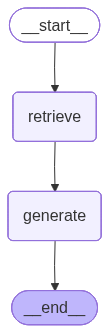

In [28]:
# Construcción del Grafo LangGraph 
builder = StateGraph(AgentState)

# Se añade los nodos
builder.add_node("retrieve", retrieve_node)
builder.add_node("generate", generate_node)

# Definición del flujo: START → retrieve → generate → END
builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "generate")
builder.add_edge("generate", END)

# Compilación del grafo
graph = builder.compile()

# Visualización del grafo (si está disponible)
display(Image(graph.get_graph().draw_mermaid_png()))

## **PASO 6 - Función de Chat con Memoria de Conversación**

La memoria se implementa manteniendo el **historial de mensajes en el estado del grafo**.
Cada turno de conversación añade al historial el par (pregunta, respuesta), permitiendo
que el agente tenga contexto de toda la conversación.

In [31]:
# Estado de la conversación (persiste entre celdas)
conversation_state = {
    'messages': [], 
    'context': '',
    'question': ''
}

def chat(pregunta: str, mostrar_contexto: bool = False) -> str:
    '''
    Función principal de chat con el agente.
    
    Args:
        pregunta: La pregunta del usuario
        mostrar_contexto: Si True, muestra los chunks recuperados de ChromaDB
    
    Returns:
        La respuesta del agente como string
    '''
    global conversation_state
    
    # Actualiza la pregunta en el estado
    conversation_state['question'] = pregunta
    
    # Invoca el grafo
    result = graph.invoke(conversation_state)
    
    # Actualiza el estado global con el nuevo historial
    conversation_state['messages'] = result['messages']
    conversation_state['context'] = result['context']
    
    # Extrae la respuesta (último mensaje AIMessage)
    respuesta = result['messages'][-1].content
    
    # Muestra la conversación
    print(f'\n{'='*60}')
    print(f'👤 USUARIO: {pregunta}')
    print(f'{'='*60}')
    
    if mostrar_contexto:
        print(f'\nCONTEXTO RAG RECUPERADO:')
        print('-'*40)
        print(result['context'][:500] + '...')
        print('-'*40)
    
    print(f'\n🤖 ASISTENTE:')
    display(Markdown(respuesta))
    print(f'\nTurnos en memoria: {len(result['messages']) // 2}')
    
    return respuesta

def reset_conversacion():
    '''Reinicia la conversación borrando el historial.'''
    global conversation_state
    conversation_state = {'messages': [], 'context': '', 'question': ''}
    print('🔄 Conversación reiniciada')

print('Funciones de chat definidas')
print('\t->chat("tu pregunta") para hacer una pregunta')
print('\t->chat("tu pregunta", mostrar_contexto=True) para ver los chunks RAG')
print('\t->reset_conversacion() para empezar de cero')

Funciones de chat definidas
	->chat("tu pregunta") para hacer una pregunta
	->chat("tu pregunta", mostrar_contexto=True) para ver los chunks RAG
	->reset_conversacion() para empezar de cero


## **PASO 7 - Ejemplos Documentados (mínimo 5 preguntas requeridas)**

A continuación se demuestran **6 interacciones** con el agente, incluyendo un ejemplo
que demuestra que la **memoria de conversación funciona correctamente**.

In [34]:
# EJEMPLO 1: Pregunta sobre proteínas
chat('¿Cuánta proteína necesita una persona que entrena fuerza 4 días a la semana y pesa 80 kg?')


👤 USUARIO: ¿Cuánta proteína necesita una persona que entrena fuerza 4 días a la semana y pesa 80 kg?

🤖 ASISTENTE:


Para una persona que entrena fuerza 4 días a la semana y pesa 80 kg, los requerimientos de proteína, basándome en el contexto proporcionado, son los siguientes:

1.  **Recomendación general para fuerza/hipertrofia:**
    *   Según la Fuente 3, para **fuerza/hipertrofia (musculación)**, la proteína recomendada es de **1.6 – 2.2 g/kg/día**.
    *   Aplicado a 80 kg:
        *   Mínimo: 80 kg * 1.6 g/kg/día = **128 gramos de proteína al día**
        *   Máximo: 80 kg * 2.2 g/kg/día = **176 gramos de proteína al día**

2.  **Recomendaciones específicas según la fase de composición corporal:**
    *   **Fase de Volumen (ganancia de masa muscular):** La proteína debe mantenerse en **1.8-2.2 g/kg/día** (Fuente 4).
        *   Aplicado a 80 kg: 80 kg * 1.8 g/kg = 144g hasta 80 kg * 2.2 g/kg = 176g. Es decir, entre **144 y 176 gramos de proteína al día**.
    *   **Fase de Definición (pérdida de grasa preservando músculo):** La proteína debe elevarse a **2.0-2.4 g/kg/día** (Fuente 3 y 4).
        *   Aplicado a 80 kg: 80 kg * 2.0 g/kg = 160g hasta 80 kg * 2.4 g/kg = 192g. Es decir, entre **160 y 192 gramos de proteína al día**.

En resumen, esta persona necesitaría entre **128 y 176 gramos de proteína al día** para el entrenamiento de fuerza en general, ajustándose a rangos más específicos si su objetivo es una fase de volumen o definición.


Turnos en memoria: 2


'Para una persona que entrena fuerza 4 días a la semana y pesa 80 kg, los requerimientos de proteína, basándome en el contexto proporcionado, son los siguientes:\n\n1.  **Recomendación general para fuerza/hipertrofia:**\n    *   Según la Fuente 3, para **fuerza/hipertrofia (musculación)**, la proteína recomendada es de **1.6 – 2.2 g/kg/día**.\n    *   Aplicado a 80 kg:\n        *   Mínimo: 80 kg * 1.6 g/kg/día = **128 gramos de proteína al día**\n        *   Máximo: 80 kg * 2.2 g/kg/día = **176 gramos de proteína al día**\n\n2.  **Recomendaciones específicas según la fase de composición corporal:**\n    *   **Fase de Volumen (ganancia de masa muscular):** La proteína debe mantenerse en **1.8-2.2 g/kg/día** (Fuente 4).\n        *   Aplicado a 80 kg: 80 kg * 1.8 g/kg = 144g hasta 80 kg * 2.2 g/kg = 176g. Es decir, entre **144 y 176 gramos de proteína al día**.\n    *   **Fase de Definición (pérdida de grasa preservando músculo):** La proteína debe elevarse a **2.0-2.4 g/kg/día** (Fuente 

In [35]:
# EJEMPLO 2: Pregunta sobre suplementación
chat('¿Vale la pena tomar creatina? ¿Qué dosis recomiendas y cuándo tomarla?')


👤 USUARIO: ¿Vale la pena tomar creatina? ¿Qué dosis recomiendas y cuándo tomarla?

🤖 ASISTENTE:


¡Absolutamente! Basándome en el contexto proporcionado, **sí, vale la pena tomar creatina**, especialmente si entrenas fuerza o realizas deportes de alta intensidad.

Aquí te detallo por qué y cómo tomarla:

**¿Vale la pena tomar creatina?**
Sí, y mucho. El contexto la describe como:
*   El suplemento con **mayor evidencia científica**, más seguro, más estudiado y más costo-efectivo del mercado (Fuente 1).
*   El suplemento deportivo **más estudiado de la historia**, con más de 500 estudios publicados (Fuente 3).
*   Un suplemento del **Grupo A**, lo que significa que su uso está justificado en el deporte de alto rendimiento debido a su fuerte evidencia (Fuente 3).

**Beneficios de la creatina:**
*   Aumenta los depósitos de fosfocreatina muscular en un 15-40% (Fuente 2).
*   Mejora el rendimiento en esfuerzos máximos y repetidos de alta intensidad (sprints, halterofilia, deporte de equipo) (Fuente 2).
*   Potencia la hipertrofia muscular al permitir un mayor volumen de entrenamiento (Fuente 2).
*   Ofrece beneficios adicionales como mejora cognitiva, neuroprotección y posibles efectos antienvejecimiento (Fuente 2).
*   Es especialmente beneficiosa para veganos, ya que está ausente en su dieta y su suplementación con 5g/día mejora su rendimiento (Fuente 4).

**¿Qué dosis recomiendo?**
La dosis recomendada es de **3-5 g/día de creatina monohidrato** (Fuente 1 y 2). Esta es la forma más económica y efectiva.

**¿Cuándo tomarla?**
*   No es necesaria una fase de carga (20 g/día x 5 días), aunque esta puede acelerar la saturación de los depósitos musculares (Fuente 2).
*   Tomarla **con carbohidratos (CHO) o una combinación de carbohidratos y proteínas (CHO+PRO)** mejora su retención muscular (Fuente 2).

En resumen, la creatina monohidrato es un suplemento altamente recomendado por su eficacia, seguridad y respaldo científico, con una dosis sencilla de 3-5g al día, preferiblemente junto con una comida que contenga carbohidratos o carbohidratos y proteínas.


Turnos en memoria: 3


'¡Absolutamente! Basándome en el contexto proporcionado, **sí, vale la pena tomar creatina**, especialmente si entrenas fuerza o realizas deportes de alta intensidad.\n\nAquí te detallo por qué y cómo tomarla:\n\n**¿Vale la pena tomar creatina?**\nSí, y mucho. El contexto la describe como:\n*   El suplemento con **mayor evidencia científica**, más seguro, más estudiado y más costo-efectivo del mercado (Fuente 1).\n*   El suplemento deportivo **más estudiado de la historia**, con más de 500 estudios publicados (Fuente 3).\n*   Un suplemento del **Grupo A**, lo que significa que su uso está justificado en el deporte de alto rendimiento debido a su fuerte evidencia (Fuente 3).\n\n**Beneficios de la creatina:**\n*   Aumenta los depósitos de fosfocreatina muscular en un 15-40% (Fuente 2).\n*   Mejora el rendimiento en esfuerzos máximos y repetidos de alta intensidad (sprints, halterofilia, deporte de equipo) (Fuente 2).\n*   Potencia la hipertrofia muscular al permitir un mayor volumen de e

In [36]:
#  EJEMPLO 3: Pregunta sobre periodización
chat('Explícame las diferencias entre periodización lineal y periodización ondulante (DUP). ¿Cuál es mejor para un deportista intermedio?')


👤 USUARIO: Explícame las diferencias entre periodización lineal y periodización ondulante (DUP). ¿Cuál es mejor para un deportista intermedio?

🤖 ASISTENTE:


Basándome en el contexto proporcionado, te explico las diferencias entre la periodización lineal y la periodización ondulante (DUP), y cuál sería más adecuada para un deportista intermedio:

### Diferencias entre Periodización Lineal y Periodización Ondulante (DUP)

**1. Periodización Lineal (Tradicional)**
*   **Origen:** Propuesta por Matveev en los años 60, es el modelo más clásico (Fuente 3).
*   **Variación de Parámetros:** El volumen disminuye progresivamente mientras la intensidad aumenta a lo largo del macrociclo (Fuente 1).
*   **Estructura de Fases:** Se organiza en fases secuenciales con objetivos distintos:
    *   **Fase Preparatoria General:** Alto volumen, baja intensidad (resistencia de base, fuerza general) (Fuente 1).
    *   **Fase Preparatoria Específica:** Volumen moderado, intensidad creciente (trabajo específico del deporte) (Fuente 1).
    *   **Fase Competitiva:** Bajo volumen, máxima intensidad, trabajo técnico-táctico (Fuente 1).
    *   **Fase de Transición:** Recuperación activa, regeneración, trabajo recreacional (Fuente 1).
*   **Público Objetivo:** Es efectiva para deportistas **novatos-intermedios** y para deportes con una sola competición anual principal (Fuente 1).

**2. Periodización Ondulante (DUP - Daily Undulating Periodization)**
*   **Variación de Parámetros:** Los parámetros de entrenamiento (volumen, intensidad, tipo de estímulo) **varían dentro del mismo microciclo** (es decir, dentro de la misma semana) (Fuente 1).
*   **Objetivos Simultáneos:** Permite desarrollar simultáneamente fuerza, hipertrofia y resistencia muscular (Fuente 2).
*   **Ejemplo Semanal:** Un ejemplo de DUP para 3 días a la semana con los mismos grupos musculares podría ser:
    *   **Lunes:** Fuerza máxima (3-5 repeticiones, 85-90% RM, 5 series) (Fuente 2).
    *   **Miércoles:** Hipertrofia (8-12 repeticiones, 70-75% RM, 4 series) (Fuente 2).
    *   **Viernes:** Resistencia muscular (15-20 repeticiones, 55-60% RM, 3 series) (Fuente 2).
*   **Público Objetivo:** Es especialmente efectiva para deportistas **intermedios-avanzados** que buscan desarrollar múltiples cualidades físicas a la vez (Fuente 2).

### ¿Cuál es mejor para un deportista intermedio?

Según el contexto:
*   La **Periodización Lineal** es efectiva para deportistas **novatos-intermedios** (Fuente 1).
*   La **Periodización Ondulante (DUP)** es especialmente efectiva para deportistas **intermedios-avanzados** (Fuente 2).

Dado que el usuario es un deportista intermedio, **ambos modelos podrían ser adecuados, pero la Periodización Ondulante (DUP) podría ofrecer una ventaja adicional**.

*   Si el deportista intermedio aún está consolidando bases y busca una progresión más estructurada y predecible, la **Periodización Lineal** podría ser un buen punto de partida.
*   Sin embargo, si el deportista intermedio ya no sostiene una progresión sesión a sesión y busca desarrollar simultáneamente fuerza, hipertrofia y resistencia muscular, la **Periodización Ondulante (DUP)** sería una opción más avanzada y efectiva, permitiendo una mayor variación y estímulo dentro de la semana (Fuente 2 y 4).

En resumen, para un deportista intermedio que busca una progresión más dinámica y el desarrollo simultáneo de varias capacidades, la **Periodización Ondulante (DUP)** es una excelente opción.


Turnos en memoria: 4


'Basándome en el contexto proporcionado, te explico las diferencias entre la periodización lineal y la periodización ondulante (DUP), y cuál sería más adecuada para un deportista intermedio:\n\n### Diferencias entre Periodización Lineal y Periodización Ondulante (DUP)\n\n**1. Periodización Lineal (Tradicional)**\n*   **Origen:** Propuesta por Matveev en los años 60, es el modelo más clásico (Fuente 3).\n*   **Variación de Parámetros:** El volumen disminuye progresivamente mientras la intensidad aumenta a lo largo del macrociclo (Fuente 1).\n*   **Estructura de Fases:** Se organiza en fases secuenciales con objetivos distintos:\n    *   **Fase Preparatoria General:** Alto volumen, baja intensidad (resistencia de base, fuerza general) (Fuente 1).\n    *   **Fase Preparatoria Específica:** Volumen moderado, intensidad creciente (trabajo específico del deporte) (Fuente 1).\n    *   **Fase Competitiva:** Bajo volumen, máxima intensidad, trabajo técnico-táctico (Fuente 1).\n    *   **Fase de

In [37]:
#  EJEMPLO 4: Pregunta sobre hidratación
chat('¿Cómo debo hidratarme si voy a correr una media maratón (21 km)?')


👤 USUARIO: ¿Cómo debo hidratarme si voy a correr una media maratón (21 km)?

🤖 ASISTENTE:


¡Excelente pregunta! La hidratación es crucial para el rendimiento en una media maratón. Basándome en el contexto proporcionado, aquí tienes una estrategia detallada:

### Estrategia de Hidratación para una Media Maratón (21 km)

Una media maratón es un ejercicio prolongado que generalmente supera los 90 minutos para la mayoría de los corredores, lo que requiere una estrategia de hidratación y aporte de carbohidratos específica.

**1. Pre-ejercicio (Antes de la Carrera):**
El objetivo es comenzar la carrera en estado de euhidratación (bien hidratado).
*   **2 horas antes:** Bebe **500 ml de agua o bebida isotónica** (Fuente 1).
*   **15-20 minutos antes:** Bebe otros **200-300 ml de agua o bebida isotónica** (Fuente 1).
*   **Indicador de hidratación:** Una orina de color amarillo pálido (como limonada) indica una hidratación adecuada (Fuente 1).

**2. Durante el Ejercicio (Durante la Carrera):**
Dado que una media maratón suele durar más de 90 minutos, las recomendaciones son las siguientes:
*   **Tipo de bebida:** Consume una **bebida isotónica** (Fuente 2).
*   **Composición de la bebida:** Debe contener **6-8% de carbohidratos (CHO)** y **500-1.000 mg/L de sodio** (Fuente 2).
*   **Cantidad:** Ingiere entre **500-1.000 ml por hora** (Fuente 2).
*   **Aporte de Carbohidratos:** Para ejercicios de 90-150 minutos (rango típico de una media maratón), se recomienda una ingesta de **60-90 g de CHO por hora**, utilizando una **mezcla de glucosa:fructosa en proporción 2:1** para maximizar la absorción intestinal (Fuente 4). La bebida isotónica ya aportará parte de estos carbohidratos.

**Consideraciones importantes durante la carrera:**
*   La tasa de sudoración individual varía enormemente (0.5 a 2.5 L/hora), por lo que es importante ajustar la ingesta a tus necesidades personales (Fuente 1).
*   Una pérdida de tan solo el 2% del peso corporal en agua (deshidratación leve) puede reducir tu rendimiento aeróbico en un 10-20% (Fuente 3).

**3. Post-ejercicio (Después de la Carrera):**
Para una rehidratación completa y una recuperación adecuada:
*   **Cantidad de líquido:** Debes reponer el **150% del peso perdido** durante el ejercicio (Fuente 2).
    *   **Ejemplo:** Si perdiste 1 kg de peso corporal durante la carrera, deberías ingerir 1.5 litros de líquido en las siguientes 2-6 horas (Fuente 2).
*   **Inclusión de sodio:** Es fundamental incluir **sodio en la bebida de recuperación (o alimentos salados)** para retener el agua ingerida y estimular la sed (Fuente 2).

Siguiendo estas pautas, podrás mantener un buen estado de hidratación y optimizar tu rendimiento en la media maratón.


Turnos en memoria: 5


'¡Excelente pregunta! La hidratación es crucial para el rendimiento en una media maratón. Basándome en el contexto proporcionado, aquí tienes una estrategia detallada:\n\n### Estrategia de Hidratación para una Media Maratón (21 km)\n\nUna media maratón es un ejercicio prolongado que generalmente supera los 90 minutos para la mayoría de los corredores, lo que requiere una estrategia de hidratación y aporte de carbohidratos específica.\n\n**1. Pre-ejercicio (Antes de la Carrera):**\nEl objetivo es comenzar la carrera en estado de euhidratación (bien hidratado).\n*   **2 horas antes:** Bebe **500 ml de agua o bebida isotónica** (Fuente 1).\n*   **15-20 minutos antes:** Bebe otros **200-300 ml de agua o bebida isotónica** (Fuente 1).\n*   **Indicador de hidratación:** Una orina de color amarillo pálido (como limonada) indica una hidratación adecuada (Fuente 1).\n\n**2. Durante el Ejercicio (Durante la Carrera):**\nDado que una media maratón suele durar más de 90 minutos, las recomendacione

In [38]:
# EJEMPLO 5: Pregunta que demuestra MEMORIA DE CONVERSACIÓN 
# Esta pregunta hace referencia a la respuesta del Ejemplo 1 sobre proteínas.
# El agente debe recordar que ya hablamos de 80 kg y entrenamiento de fuerza.
chat('Y para esa misma persona de la que hablamos antes, ¿qué alimentos concretos le recomendarías para llegar a ese objetivo proteico sin usar batidos?')


👤 USUARIO: Y para esa misma persona de la que hablamos antes, ¿qué alimentos concretos le recomendarías para llegar a ese objetivo proteico sin usar batidos?

🤖 ASISTENTE:


Para la persona de 80 kg que entrena fuerza 4 días a la semana, el objetivo proteico recomendado es de **128 a 176 gramos de proteína al día** (basado en 1.6-2.2 g/kg/día).

Para alcanzar este objetivo sin necesidad de batidos, puedes basarte en los siguientes alimentos concretos y sus aportes proteicos, según el contexto proporcionado:

**Alimentos ricos en proteína y sus aportes aproximados:**

*   **Huevos:**
    *   3 huevos: aproximadamente **18g de proteína** (Fuente 1).
    *   (Un desayuno con 3 huevos revueltos, avena y leche puede aportar hasta 35g, Fuente 4).
*   **Pechuga de pollo:**
    *   150g de pechuga de pollo: aproximadamente **37g de proteína** (Fuente 1).
    *   (150g de pechuga de pollo con arroz y manzana aporta 40g, Fuente 4).
*   **Yogur griego:**
    *   200g de yogur griego: aproximadamente **20g de proteína** (Fuente 1).
    *   (1 yogur griego con fruta y chía aporta 14g, Fuente 3).
*   **Atún en lata:**
    *   200g de atún en lata: aproximadamente **42g de proteína** (Fuente 1).
    *   (También mencionado en ensalada con lentejas, Fuente 3).
*   **Queso:**
    *   30g de queso: aproximadamente **7g de proteína** (Fuente 1).
    *   200g de queso fresco 0%: aproximadamente **22g de proteína** (Fuente 4).
*   **Lentejas:**
    *   200g de lentejas cocidas: aproximadamente **32g de proteína** (Fuente 3).
*   **Pescado (Merluza/Salmón):**
    *   150g de merluza al horno: aproximadamente **38g de proteína** (Fuente 3).
    *   200g de salmón: alto en proteína (mencionado en Fuente 4, aunque no se detalla el gramaje exacto de proteína para esa porción).
*   **Leche semidesnatada:** Aporta proteína, especialmente si se consume con otros alimentos como avena (Fuente 4).
*   **Semillas de chía:** Aportan proteína (mencionado en Fuente 3).
*   **Nueces:** Aportan proteína (mencionado en Fuente 4).

**Ejemplo de distribución para alcanzar el objetivo (aproximadamente 150-160g de proteína):**

Podrías estructurar tus comidas de la siguiente manera, combinando estos alimentos:

*   **Desayuno:**
    *   3 huevos revueltos (18g)
    *   100g de avena con 200ml de leche semidesnatada (aportes adicionales de proteína)
*   **Almuerzo:**
    *   150g de pechuga de pollo (37g)
    *   200g de lentejas cocidas (32g) en una ensalada
*   **Merienda:**
    *   200g de yogur griego (20g)
    *   200g de atún en lata (42g)
*   **Cena:**
    *   150g de merluza al horno (38g) o 200g de salmón

Esta combinación sumaría aproximadamente **18 + 37 + 32 + 20 + 42 + 38 = 187 gramos de proteína**, lo cual está en el rango superior de tu objetivo y demuestra que es totalmente factible alcanzarlo con alimentos enteros.

Recuerda que la distribución de la proteína a lo largo del día en varias tomas (por ejemplo, 4 tomas como se sugiere en Fuente 2) es beneficiosa para optimizar la síntesis proteica muscular.


Turnos en memoria: 6


'Para la persona de 80 kg que entrena fuerza 4 días a la semana, el objetivo proteico recomendado es de **128 a 176 gramos de proteína al día** (basado en 1.6-2.2 g/kg/día).\n\nPara alcanzar este objetivo sin necesidad de batidos, puedes basarte en los siguientes alimentos concretos y sus aportes proteicos, según el contexto proporcionado:\n\n**Alimentos ricos en proteína y sus aportes aproximados:**\n\n*   **Huevos:**\n    *   3 huevos: aproximadamente **18g de proteína** (Fuente 1).\n    *   (Un desayuno con 3 huevos revueltos, avena y leche puede aportar hasta 35g, Fuente 4).\n*   **Pechuga de pollo:**\n    *   150g de pechuga de pollo: aproximadamente **37g de proteína** (Fuente 1).\n    *   (150g de pechuga de pollo con arroz y manzana aporta 40g, Fuente 4).\n*   **Yogur griego:**\n    *   200g de yogur griego: aproximadamente **20g de proteína** (Fuente 1).\n    *   (1 yogur griego con fruta y chía aporta 14g, Fuente 3).\n*   **Atún en lata:**\n    *   200g de atún en lata: aprox

In [39]:
# EJEMPLO 6: Pregunta sobre recuperación con contexto RAG visible
chat(
    'Estoy muy cansado siempre después de entrenar. ¿Qué puede estar fallando?',
    mostrar_contexto=True  # Mostramos los chunks recuperados de ChromaDB
)


👤 USUARIO: Estoy muy cansado siempre después de entrenar. ¿Qué puede estar fallando?

CONTEXTO RAG RECUPERADO:
----------------------------------------
[Fuente 1: Documento desconocido | Pág. 6]
 Falta de sueño: menos de 7-8 horas compromete la recuperación hormonal y neuromuscular.
 Déficit de hierro: causa muy frecuente en mujeres deportistas. Analítica recomendada.
 Déficit de vitamina D: niveles < 20 ng/mL se asocian con fatiga muscular y general.
 Sobreentrenamiento: demasiado volumen/intensidad sin suficiente recuperación.
 Hipotiroidismo o anemia: causas médicas que requieren evaluación profesional.
Plan de acción recomendado: 1) Ca...
----------------------------------------

🤖 ASISTENTE:


Entiendo que te sientes muy cansado después de entrenar, lo cual es una señal importante de que algo podría no estar funcionando correctamente en tu recuperación o nutrición. Basándome en el contexto proporcionado, la fatiga crónica post-entrenamiento puede tener múltiples causas.

Aquí te detallo las posibles razones y un plan de acción recomendado:

### Posibles causas de la fatiga post-entrenamiento:

1.  **Déficit Nutricionales y Energéticos:**
    *   **Déficit calórico excesivo:** Entrenar con menos de 1.500 kcal/día hace que la fatiga sea inevitable (Fuente 2). Una disponibilidad energética baja (< 30 kcal/kg masa libre de grasa) también aumenta el riesgo de fatiga muscular (Fuente 4).
    *   **Déficit de carbohidratos (CHO):** Una restricción severa de carbohidratos con entrenamiento intenso agota el glucógeno, que es la principal fuente de energía (Fuente 2).
    *   **Proteína insuficiente:** Una ingesta proteica baja compromete la capacidad de reparar los microdaños musculares, aumentando el tiempo de recuperación entre sesiones (Fuente 3).
    *   **Déficit de antioxidantes:** Puede llevar a un mayor daño oxidativo en el tejido muscular y conectivo con el entrenamiento intenso (Fuente 4).

2.  **Falta de Recuperación y Sueño:**
    *   **Falta de sueño:** Dormir menos de 7-8 horas compromete significativamente la recuperación hormonal y neuromuscular (Fuente 1 y 2).
    *   **Sobreentrenamiento:** Demasiado volumen o intensidad de entrenamiento sin suficiente recuperación es una causa común de fatiga (Fuente 1).

3.  **Problemas de Hidratación:**
    *   **Deshidratación:** Aumenta el riesgo de calambres, tirones musculares y deterioro de la concentración (Fuente 4).

4.  **Deficiencias de Micronutrientes y Condiciones Médicas:**
    *   **Déficit de hierro:** Es una causa muy frecuente, especialmente en mujeres deportistas (Fuente 1).
    *   **Déficit de vitamina D:** Niveles por debajo de 20 ng/mL se asocian con fatiga muscular y general (Fuente 1).
    *   **Hipotiroidismo o anemia:** Son causas médicas que requieren una evaluación profesional (Fuente 1).

### Plan de acción recomendado:

Para abordar esta fatiga, el contexto sugiere los siguientes pasos:

1.  **Evalúa tu ingesta calórica:** Calcula tu Gasto Energético Total (GET) y asegúrate de que tu ingesta calórica sea adecuada para tus niveles de actividad (Fuente 1). Evita déficits calóricos excesivos.
2.  **Optimiza tus carbohidratos:** Incluye carbohidratos en tus comidas pre y post-entrenamiento para asegurar la reposición de glucógeno (Fuente 1).
3.  **Prioriza el sueño:** Asegúrate de dormir al menos 8 horas diarias para una óptima recuperación hormonal y neuromuscular (Fuente 1).
4.  **Realiza una analítica completa:** Es fundamental para descartar deficiencias. Solicita a tu médico un análisis de sangre que incluya hierro, ferritina, vitamina D, TSH (hormona tiroidea) y un hemograma completo (Fuente 1).
5.  **Revisa tu entrenamiento:** Considera si estás realizando demasiado volumen o intensidad sin la recuperación adecuada (sobreentrenamiento).
6.  **Consulta a un profesional:** Si la fatiga persiste por más de 4 semanas a pesar de aplicar estas medidas, es crucial que consultes con un médico deportivo para una evaluación más profunda (Fuente 1).

Espero que esta información te sea de gran ayuda para identificar la causa de tu fatiga y empezar a sentirte mejor.


Turnos en memoria: 7


'Entiendo que te sientes muy cansado después de entrenar, lo cual es una señal importante de que algo podría no estar funcionando correctamente en tu recuperación o nutrición. Basándome en el contexto proporcionado, la fatiga crónica post-entrenamiento puede tener múltiples causas.\n\nAquí te detallo las posibles razones y un plan de acción recomendado:\n\n### Posibles causas de la fatiga post-entrenamiento:\n\n1.  **Déficit Nutricionales y Energéticos:**\n    *   **Déficit calórico excesivo:** Entrenar con menos de 1.500 kcal/día hace que la fatiga sea inevitable (Fuente 2). Una disponibilidad energética baja (< 30 kcal/kg masa libre de grasa) también aumenta el riesgo de fatiga muscular (Fuente 4).\n    *   **Déficit de carbohidratos (CHO):** Una restricción severa de carbohidratos con entrenamiento intenso agota el glucógeno, que es la principal fuente de energía (Fuente 2).\n    *   **Proteína insuficiente:** Una ingesta proteica baja compromete la capacidad de reparar los microdañ

---

In [5]:
# LLM y Embeddings
llm = ChatGoogleGenerativeAI(
    model=MODEL, 
    temperature=0, google_api_key=API_KEY
    )

embeddings = GoogleGenerativeAIEmbeddings(
    model=MODEL, 
    google_api_key=API_KEY)

In [ ]:
# Base de conocimiento vectorial: ChromaDB
vectorstore = Chroma.from_documents(
    documents = documentos, # Generar documentos
    embedding = embeddings,
    collection_name = 'master_ia_doc' # Cambiar
)

In [ ]:
# Framework de agente: LangGraph (Ccon LangChain como base)
@tool
def buscar_documentacion(query: str) -> str:
    '''
    Busca información relevante en la documentación del **master de IA**.
    Úsala cuando necesites información sobre LangChain, RAG, LangGraph, embeddings, **AWS BedRock**
    '''
    docs = retriever.invoke(query)
    if not docs:
        return 'No enocntré información relevante sobre se tema'
    
    resultados = []

    for i, doc in enumerate(docs,1):
        fuente = doc.metadata.get('source', 'desconocida')
        resultados.append(f'[Fuente: {fuente}] \n {doc.page_content}')

    return '\n\n'.join(resultados)

In [ ]:
resultado = buscar_documentacion.invoke({'query': '¿Qué es el RAG'}) # Cambiar

In [ ]:
system_prompt = '''
Eres un asistente experto en **IA Generativa para un máster universitario**.
Tienes acceso a documentación del *máster**^. Cuando el usuario pregunta algo técnico, SIEMPRE usa la herramienta,
`buscar_documentacion` para fundamentar tu respuesta. Si la pregunta es de conversación general, puedes responder
directamente. 
Responde siempre en español
'''

In [ ]:
agente_rag = create_agent(
    model=llm,
    tools=[buscar_documentacion],
    system_prompt=system_prompt
)

In [ ]:
def preguntar_al_agente(pregunta: str):
    '''
    Función helper para hacer preguntas al agente y ver el proceso
    '''
    print('\n{"="*60}')
    print(f'PRegunta: {pregunta}')
    print('='*60)

    respuesta = agente_rag.invoke({
        'messages': [HumanMessage(content=pregunta)]
    })

    # Mostrar el proceso paso a paso
    print('\nProceso del agente:')
    for msg in respuesta['messages']:
        tipo = msg.__class__.__name__
        if tipo == 'HumanMessage':
            print(f'Usuario: {msg.content[:100]}')
        elif tipo == 'AIMessage':
            if msg.tool_calls:
                for tc in msg.tool_calls:
                    print(f'Agente decide usar herramientas: {tc['name']}')
                    print(f' Query: {tc['args'].get('query', '')}')

            else:
                print(f'\n Respuesta final: \n {msg.content}')
        elif tipo == 'ToolMessage':
            print(f'Resultado recuperado: {msg.content[:150]}...')

In [ ]:
# Pregunta 1: Requiere búsqueda
preguntar_al_agente('Que ingredienes tiene la toritll de patata?') # Cambiar